In [19]:
import json
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("../style/style-formal.mplstyle")

In [20]:
def calc_afl_perf_from_json(results, reproduced_bugs=None, ks=[1, 2, 3, 4, 5]):
    bug2min_afl_rank = dict()
    for bug_name in results["buggy_methods"]:
        if len(results["buggy_methods"][bug_name]) == 0:
            continue
        if reproduced_bugs is not None and bug_name not in reproduced_bugs:
            continue
        min_afl_rank = min(
            [
                v["autofl_rank"]
                for method_name, v in results["buggy_methods"][bug_name].items()
            ]
        )
        bug2min_afl_rank[bug_name] = min_afl_rank

    afl_perf = [
        len([v for bug_name, v in bug2min_afl_rank.items() if (v <= k)]) for k in ks
    ]
    return afl_perf

def visualize_performance(exp_list, score_data, repetition, fig_title, legend_loc):
    plt.figure(figsize=(7, 5))
    for exp in exp_list:
        score = calc_afl_perf_from_json(score_data[exp['name']])
        plt.plot(
            range(1, 6),
            score,
            "x-",
            label=f"{exp.get('label') or exp.get('name')} (x{repetition})",
        )

    plt.legend(loc=legend_loc, fontsize=12, frameon=True)

    plt.xlabel("k", fontsize=14)
    plt.ylabel("acc@k", fontsize=14)
    plt.xticks(range(1, 6), fontsize=12)
    plt.yticks(fontsize=12)
    plt.title(fig_title, fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [21]:
def calc_mrr(data):
    """
    Calculate MRR (Mean Reciprocal Rank)
    """
    total_rr = 0.0
    bug_cnt = 0

    for bug_name, method_info in data.get("buggy_methods", {}).items():
        if not method_info:
            continue
        
        # Collect ranks for all suspicious elements of this bug
        ranks = [
            info.get("autofl_rank")
            for info in method_info.values()
            if isinstance(info, dict) and info.get("autofl_rank") is not None
        ]

        if not ranks:
            continue

        best_rank = min(ranks)

        # reciprocal rank
        rr = 1.0 / best_rank

        total_rr += rr
        bug_cnt += 1

    if bug_cnt == 0:
        return 0.0

    return total_rr / bug_cnt


In [22]:
def calc_acc_at_n(data, n_rank=1):
    """
    Calculate Acc@N (Accuracy at N)
    Returns success bug count / total bug count
    """
    total_bug_cnt = 0
    success_cnt = 0

    for bug_name, method_info in data.get("buggy_methods", {}).items():
        if not method_info:
            continue

        total_bug_cnt += 1
        
        ranks = [
            info.get("autofl_rank")
            for info in method_info.values()
            if isinstance(info, dict) and info.get("autofl_rank") is not None
        ]
        
        if ranks:
            best_rank = min(ranks)
        else:
            continue
            
        if best_rank <= n_rank:
            success_cnt += 1

    if total_bug_cnt == 0:
        return 0.0, 0
    else:
        return round(success_cnt / total_bug_cnt, 3), success_cnt

In [23]:
def calc_ap(data):
    """
    Calculate Average Precision (AP)
    """
    result = {}

    for bug_name, method_info in data.get("buggy_methods", {}).items():
        if not method_info:
            continue
        
        result[bug_name] = []

        # Collect ranks for all suspicious elements of this bug
        ranks = [
            info.get("autofl_rank")
            for info in method_info.values()
            if isinstance(info, dict) and info.get("autofl_rank") is not None
        ]
        ranks.sort()
        for index, autofl_rank in enumerate(ranks):
            if autofl_rank is not None:
                val = (index + 1) / autofl_rank
                result[bug_name].append(val)

    total = 0
    cnt = 0
    for bug_name in result:
        ap_list = result[bug_name]
        total += sum(ap_list)
        cnt += len(ap_list)

    return total / cnt

In [24]:
def calc_map(data):
    """
    Compute Mean Average Precision (MAP)
    """
    ap_values = []

    for bug_name, method_info in data.get("buggy_methods", {}).items():
        if not method_info:
            continue

        # Collect absolute ranks of faulty methods
        ranks = [
            info.get("autofl_rank")
            for info in method_info.values()
            if isinstance(info, dict) and info.get("autofl_rank") is not None
        ]
        ranks.sort()

        # AP computation
        ap_sum = 0.0
        for idx, autofl_rank in enumerate(ranks, start=1):
            if autofl_rank is not None:
                ap_sum += (idx / autofl_rank)

        ap_i = ap_sum / len(ranks)
        ap_values.append(ap_i)

    if not ap_values:
        return 0.0

    return round(sum(ap_values) / len(ap_values), 6)

In [25]:
def main(exp_list, repetition=1, fig_title="Performance for GPT 4.1", legend_loc="lower right"):
    results = []
    score_data = {}
    for exp in exp_list:
        score_path_json = f"../combined_fl_results/{exp['name']}/{exp['gpt_version']}_R{repetition}_full_light.json"
        with open(score_path_json, "r") as f:
            data = json.load(f)
            score_data[exp['name']] = data
            
        map = round(calc_map(data), 3)
        acc_1_ratio, acc_1_value = calc_acc_at_n(data, 1)
        acc_2_ratio, acc_2_value = calc_acc_at_n(data, 2)
        acc_3_ratio, acc_3_value = calc_acc_at_n(data, 3)
        acc_4_ratio, acc_4_value = calc_acc_at_n(data, 4)
        acc_5_ratio, acc_5_value = calc_acc_at_n(data, 5)
        mrr = round(calc_mrr(data), 3)


        result = {
            "label": exp["label"],
            "Acc@1": acc_1_value,
            "Acc@2": acc_2_value,
            "Acc@3": acc_3_value,
            "Acc@4": acc_4_value,
            "Acc@5": acc_5_value,
            "Mean Reciprocal Rank (MRR)": mrr,
            "Mean Average Precision (MAP)": map,
        }
        results.append(result)
        
    visualize_performance(exp_list=exp_list, score_data=score_data, repetition=repetition, fig_title=fig_title, legend_loc=legend_loc)

    summary = pd.DataFrame([res for res in results ])
    column_order = ["label", "Acc@1", "Acc@2", "Acc@3", "Acc@4", "Acc@5", "Mean Reciprocal Rank (MRR)", "Mean Average Precision (MAP)"]
    summary = summary.reindex(columns=column_order)
    display(summary)
    print()


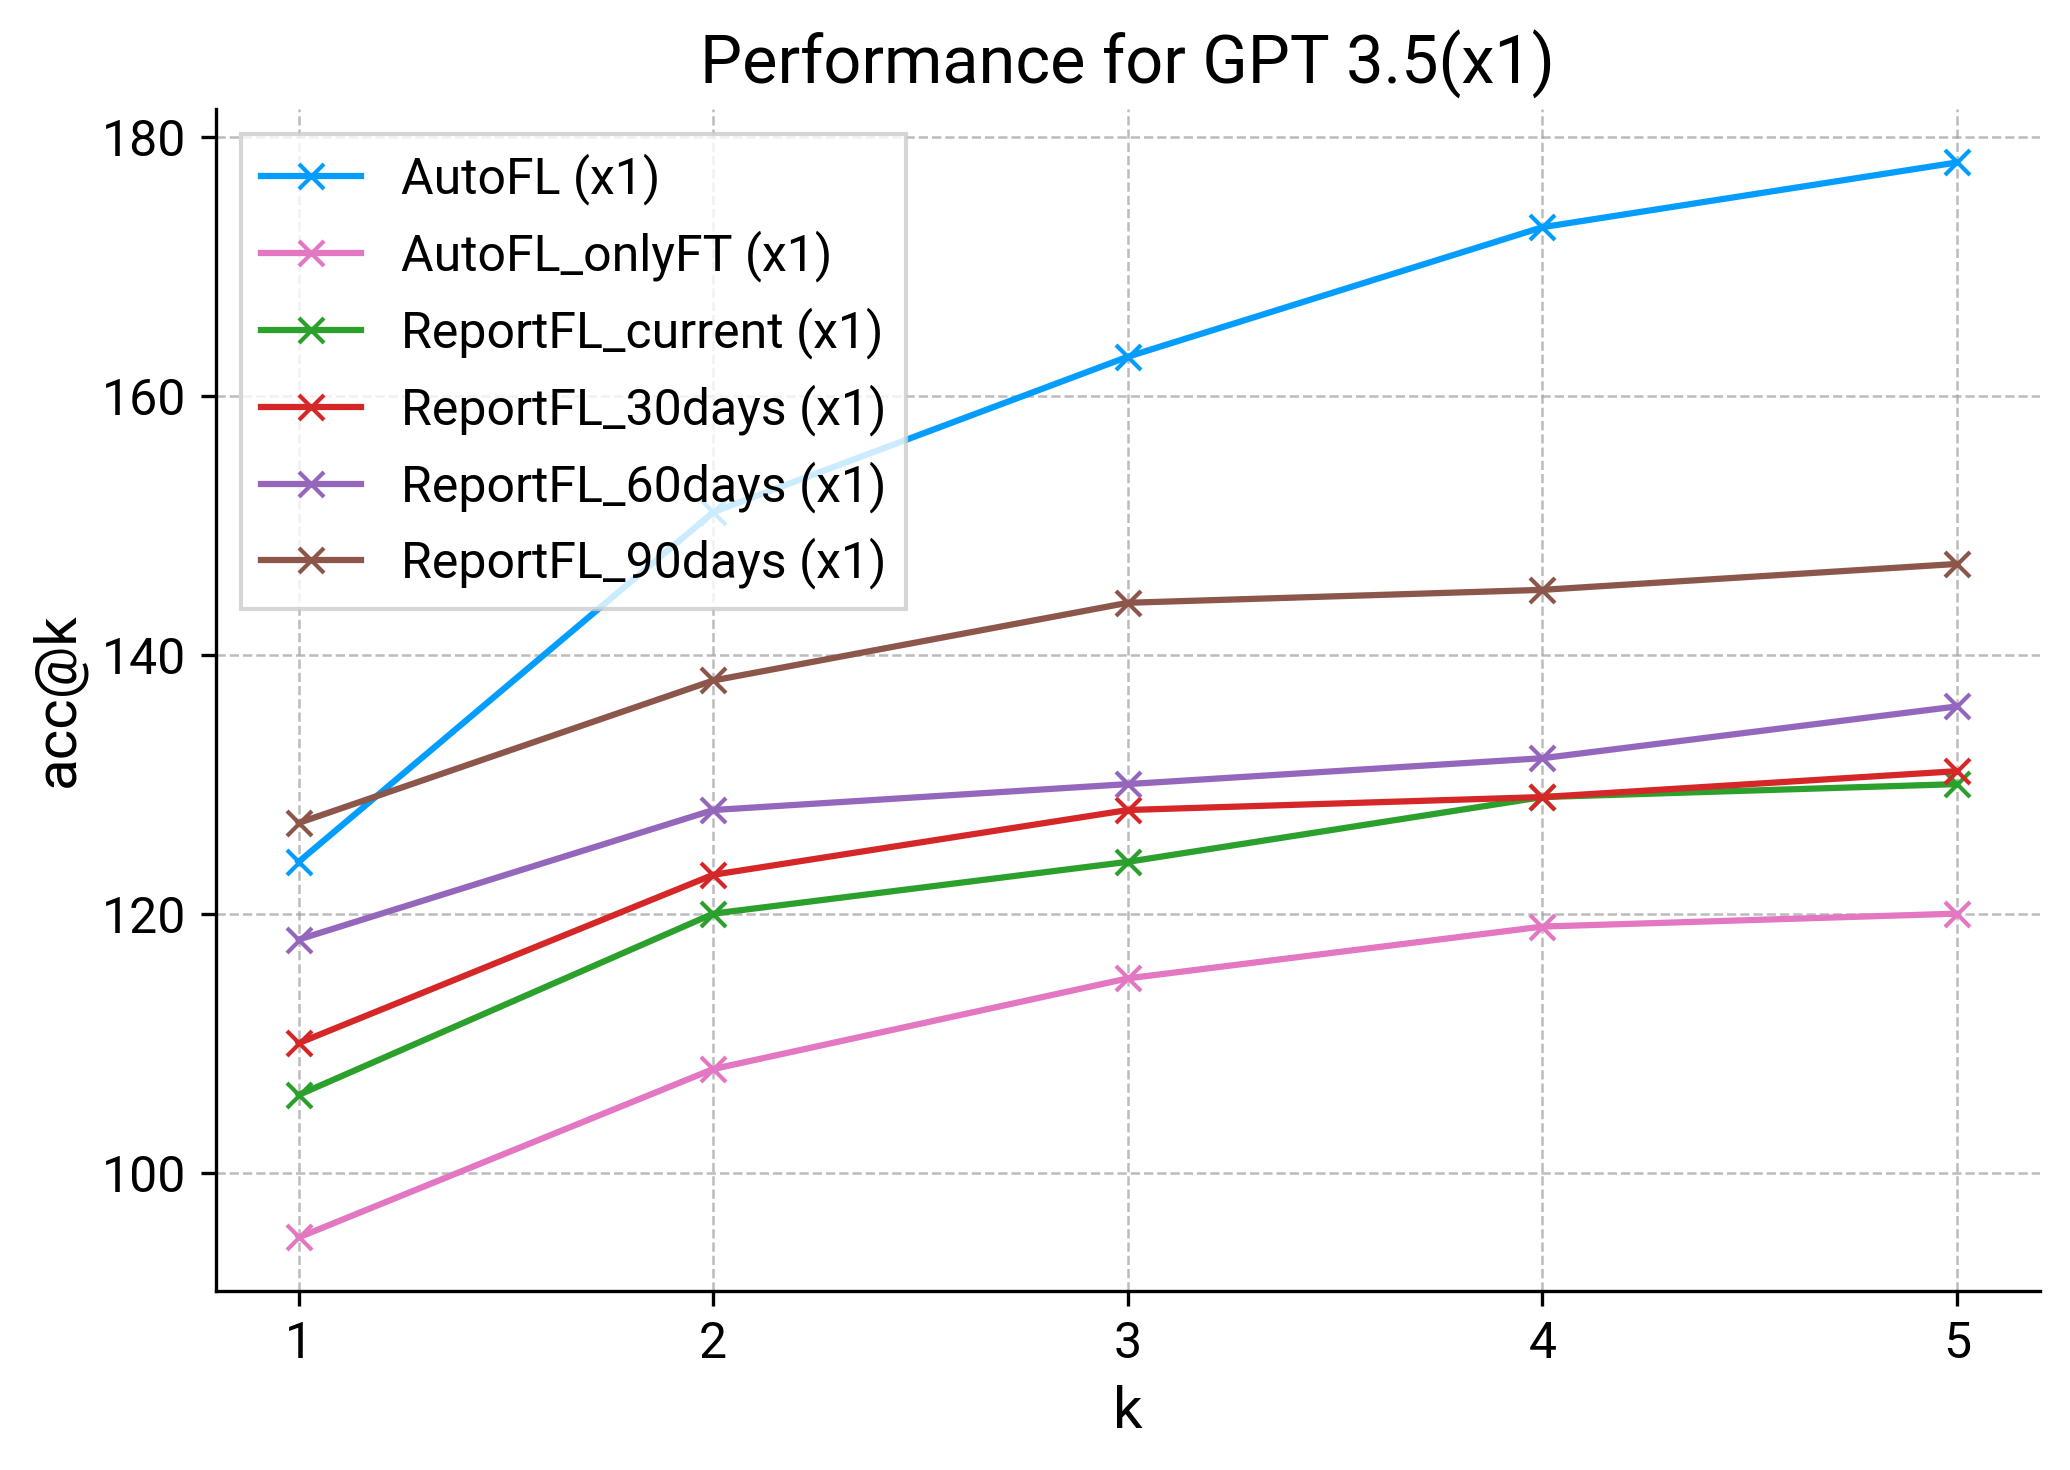

,label,Acc@1,Acc@2,Acc@3,Acc@4,Acc@5,Mean Reciprocal Rank (MRR),Mean Average Precision (MAP)
0,AutoFL,124,151,163,173,178,0.521,0.493
1,AutoFL_onlyFT,95,108,115,119,120,0.370,0.334
2,ReportFL_current,106,120,124,129,130,0.411,0.372
3,ReportFL_30days,110,123,128,129,131,0.418,0.368
4,ReportFL_60days,118,128,130,132,136,0.439,0.388
5,ReportFL_90days,127,138,144,145,147,0.475,0.424


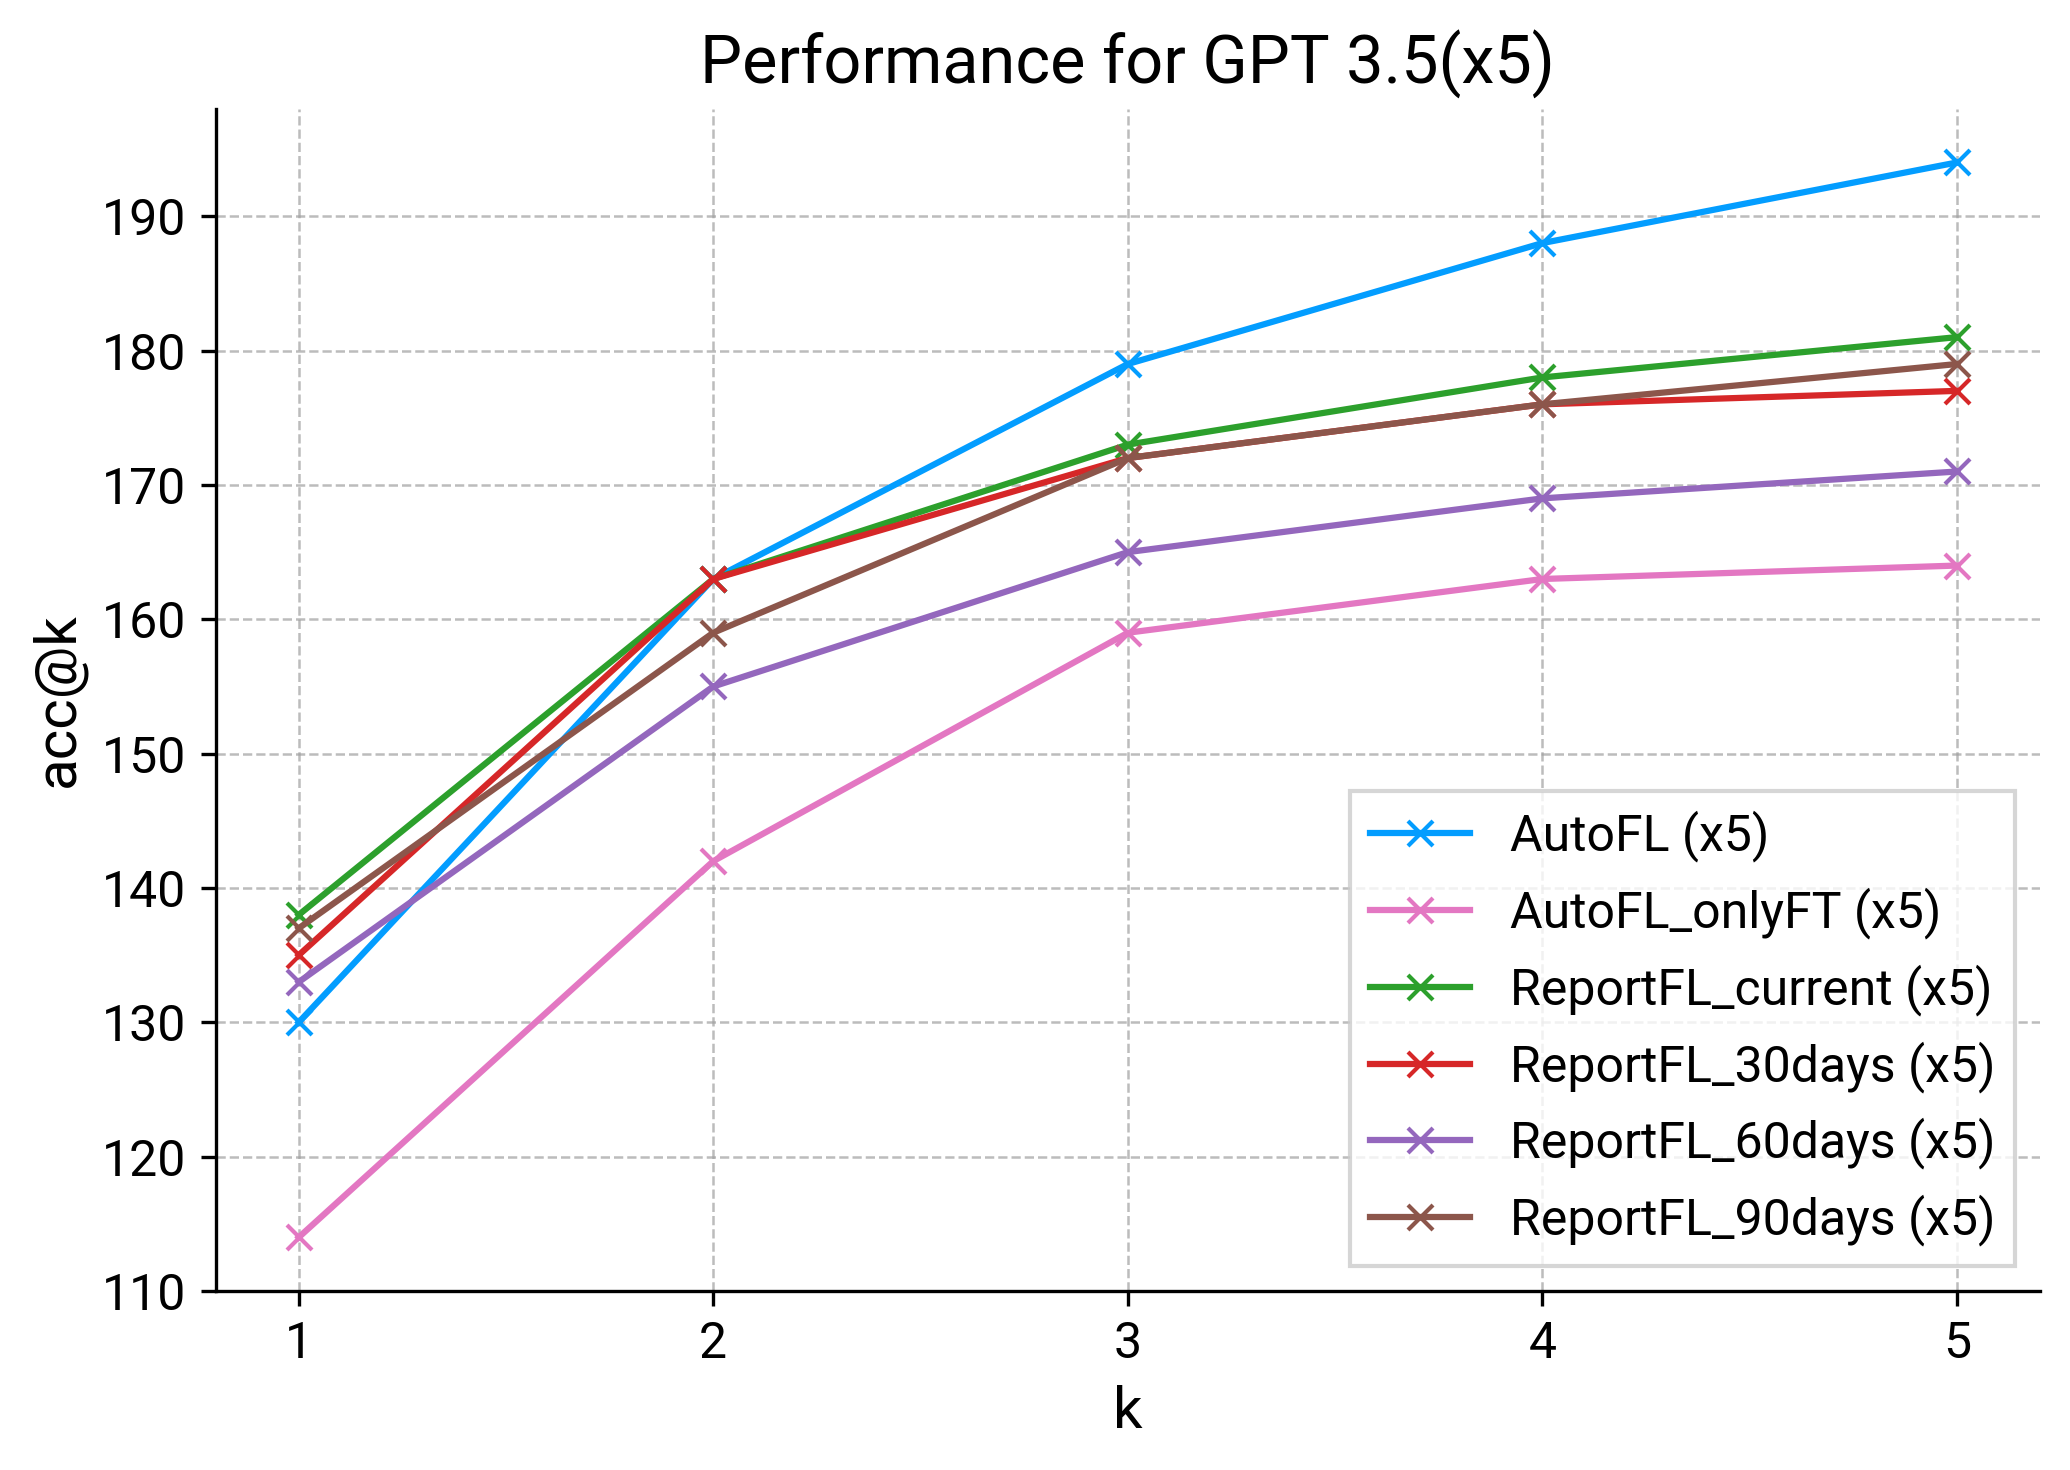

,label,Acc@1,Acc@2,Acc@3,Acc@4,Acc@5,Mean Reciprocal Rank (MRR),Mean Average Precision (MAP)
0,AutoFL,130,163,179,188,194,0.553,0.535
1,AutoFL_onlyFT,114,142,159,163,164,0.467,0.426
2,ReportFL_current,138,163,173,178,181,0.545,0.505
3,ReportFL_30days,135,163,172,176,177,0.537,0.493
4,ReportFL_60days,133,155,165,169,171,0.522,0.487
5,ReportFL_90days,137,159,172,176,179,0.538,0.496


In [26]:
EXP_LIST = [
    {
        "name": "autofl",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "AutoFL",
    },
    {
        "name": "autofl_onlyft",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "AutoFL_onlyFT",
    },
    {
        "name": "current",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_current",
    },
    {
        "name": "reportfl",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_30days",
    },    
    {
        "name": "reportfl_60days",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_60days",
    },
    {
        "name": "reportfl_90days",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_90days",
    }
]

main(exp_list=EXP_LIST, repetition=1, fig_title="Performance for GPT 3.5(x1)", legend_loc="upper left")
main(exp_list=EXP_LIST, repetition=5, fig_title="Performance for GPT 3.5(x5)")

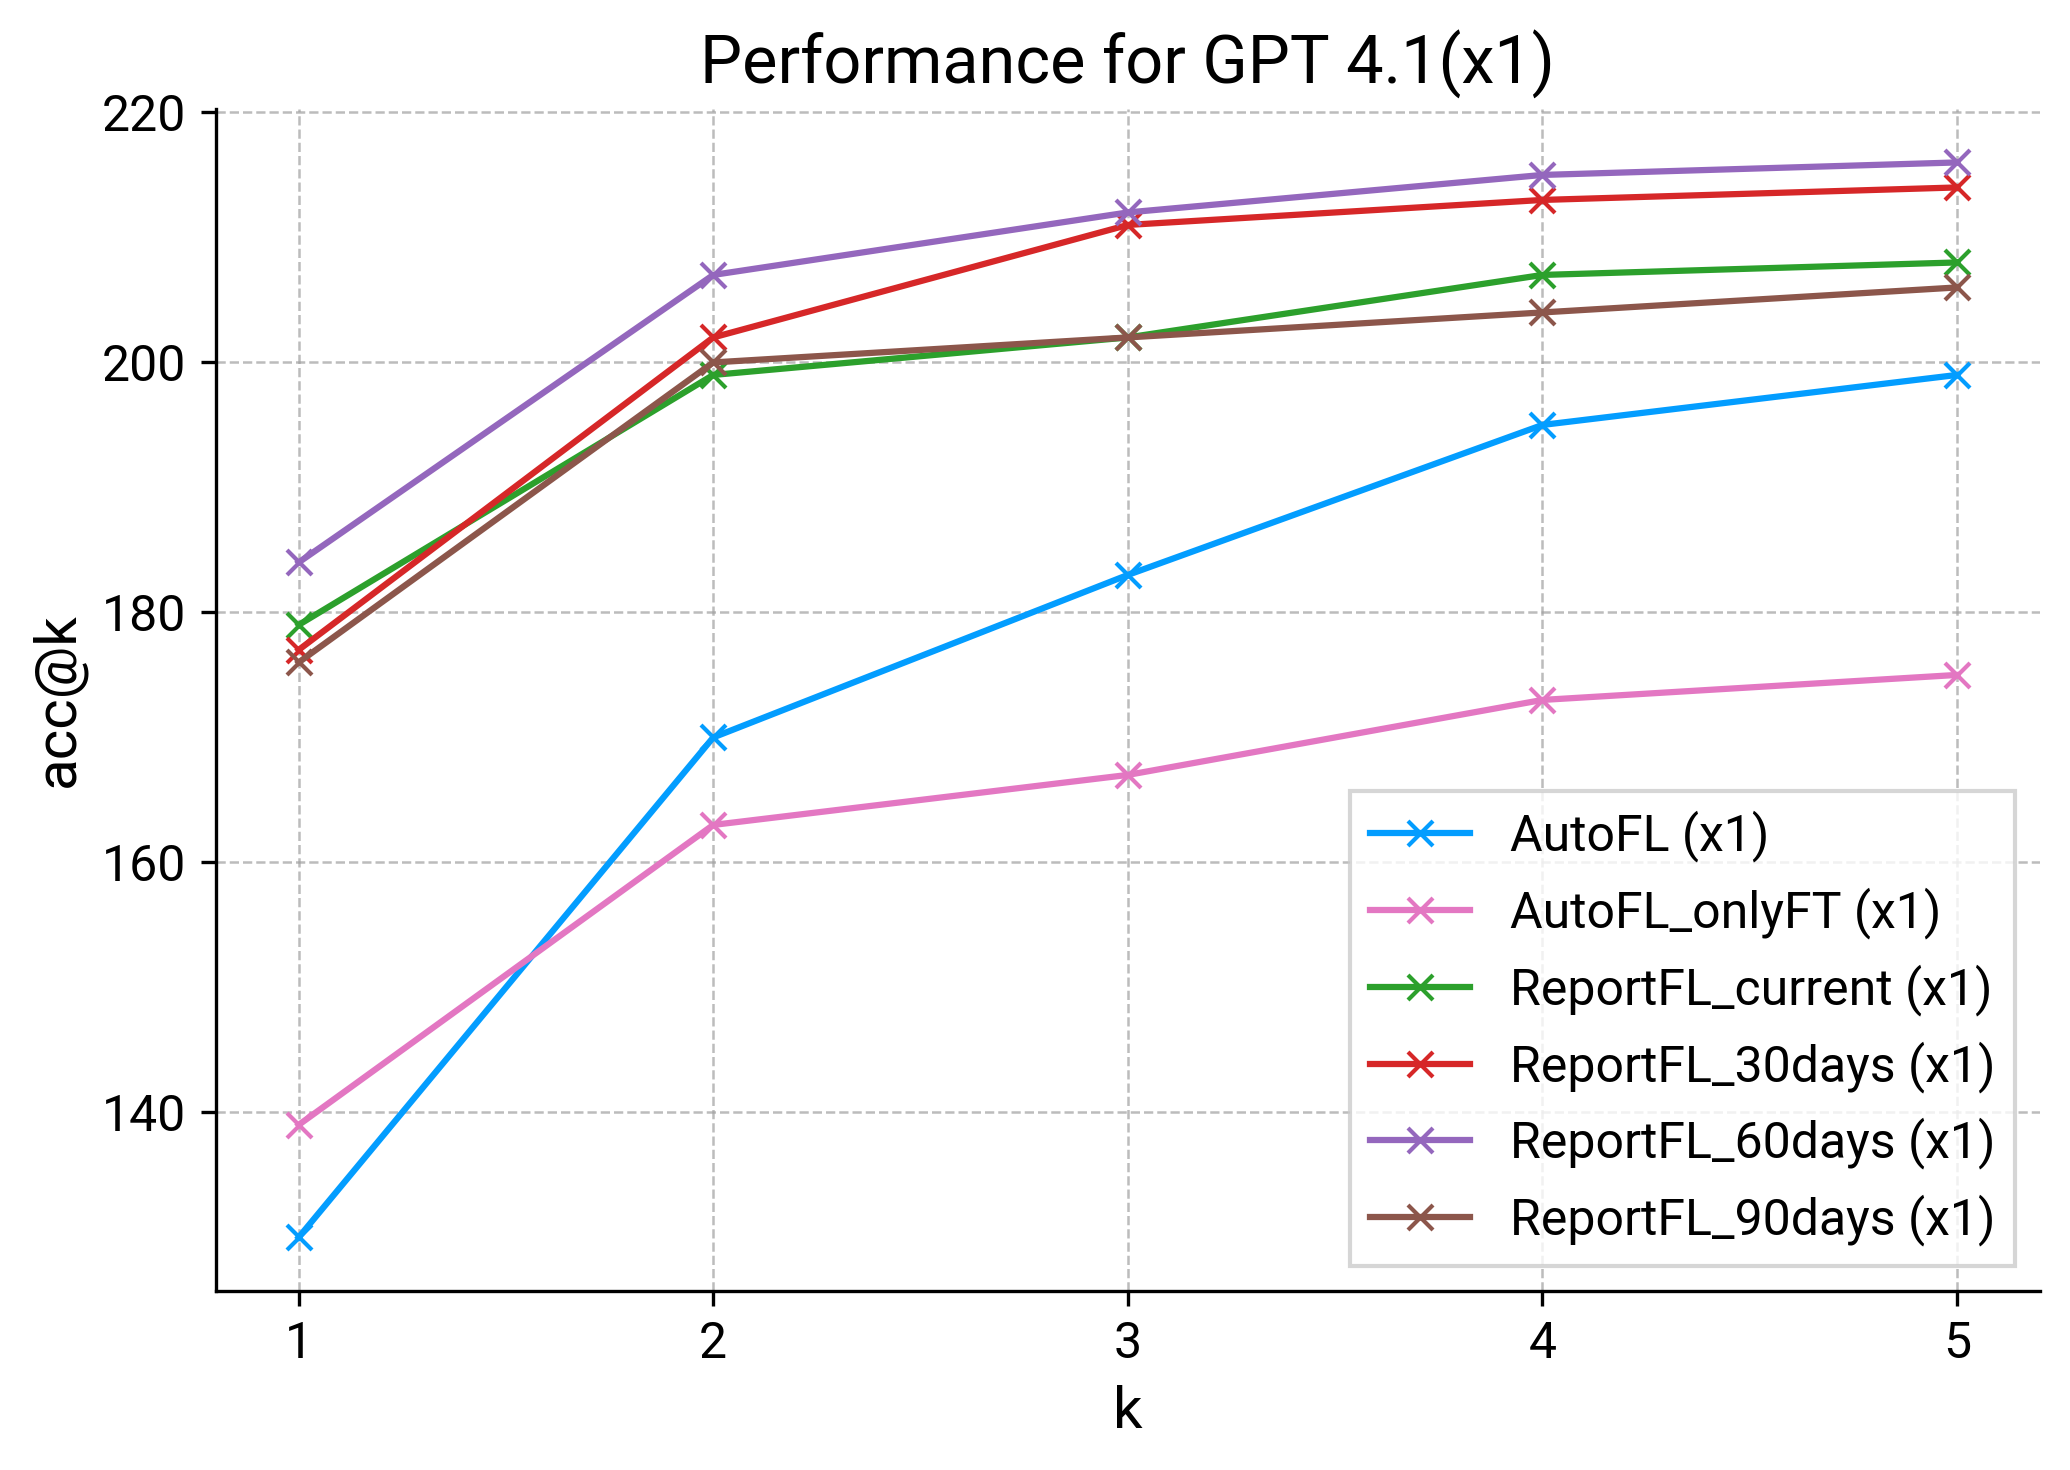

,label,Acc@1,Acc@2,Acc@3,Acc@4,Acc@5,Mean Reciprocal Rank (MRR),Mean Average Precision (MAP)
0,AutoFL,130,170,183,195,199,0.561,0.535
1,AutoFL_onlyFT,139,163,167,173,175,0.539,0.477
2,ReportFL_current,179,199,202,207,208,0.666,0.601
3,ReportFL_30days,177,202,211,213,214,0.673,0.604
4,ReportFL_60days,184,207,212,215,216,0.689,0.612
5,ReportFL_90days,176,200,202,204,206,0.660,0.587


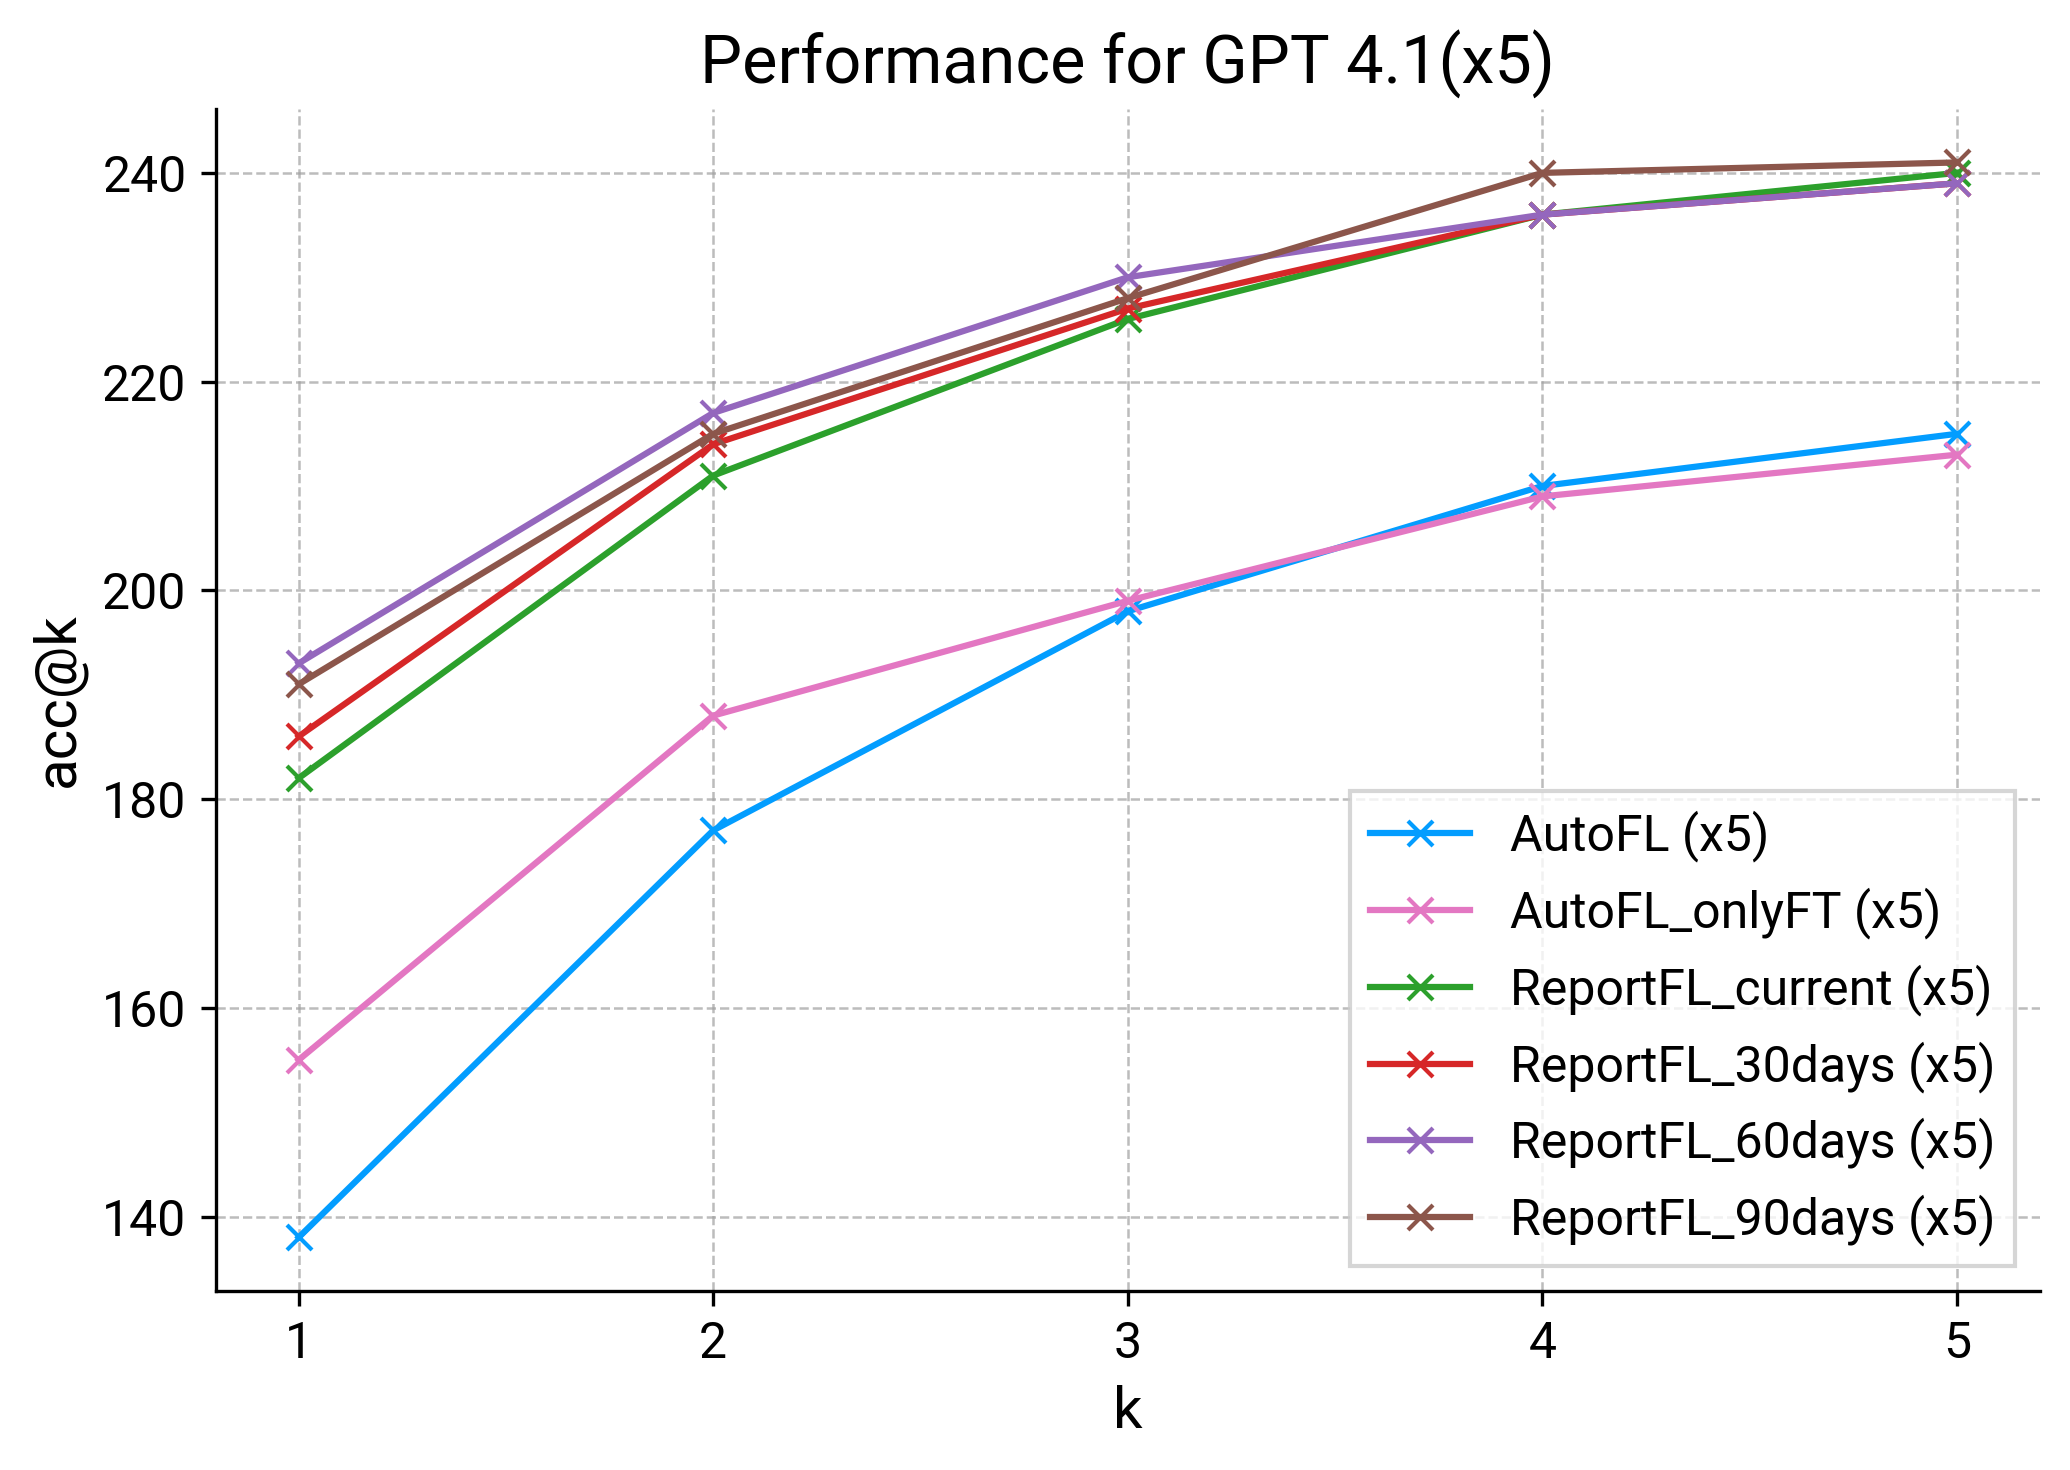

,label,Acc@1,Acc@2,Acc@3,Acc@4,Acc@5,Mean Reciprocal Rank (MRR),Mean Average Precision (MAP)
0,AutoFL,138,177,198,210,215,0.596,0.580
1,AutoFL_onlyFT,155,188,199,209,213,0.622,0.576
2,ReportFL_current,182,211,226,236,240,0.713,0.659
3,ReportFL_30days,186,214,227,236,239,0.720,0.664
4,ReportFL_60days,193,217,230,236,239,0.734,0.684
5,ReportFL_90days,191,215,228,240,241,0.732,0.680


In [27]:
EXP_LIST = [
    {
        "name": "autofl",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "AutoFL",
    },
    {
        "name": "autofl_onlyft",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "AutoFL_onlyFT",
    },
    {
        "name": "current",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_current",
    },
    {
        "name": "reportfl",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_30days",
    },    
    {
        "name": "reportfl_60days",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_60days",
    },
    {
        "name": "reportfl_90days",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_90days",
    }
]

main(exp_list=EXP_LIST, repetition=1, fig_title="Performance for GPT 4.1(x1)")
main(exp_list=EXP_LIST, repetition=5, fig_title="Performance for GPT 4.1(x5)")